<a href="https://colab.research.google.com/github/11icy/ML/blob/main/Prediction_Pannes_Industrielles_ML_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

In [32]:
df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [33]:
print(df.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [34]:
df = df.drop(["UDI", "Product ID"], axis=1)

df = pd.get_dummies(df, columns=["Type"], drop_first=True)

X = df.drop(["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)
y = df["Machine failure"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "MLP ReLU": MLPClassifier(hidden_layer_sizes=(64,), activation="relu", max_iter=300, random_state=42),
    "MLP Tanh": MLPClassifier(hidden_layer_sizes=(64,), activation="tanh", max_iter=300, random_state=42),
    "MLP Sigmoid": MLPClassifier(hidden_layer_sizes=(64,), activation="logistic", max_iter=300, random_state=42)
}

In [37]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Modèle": name,
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Modèle,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.102941,0.177215,0.899449
1,MLP ReLU,0.529412,0.642857,0.975543
2,MLP Tanh,0.573529,0.624000,0.966204
3,MLP Sigmoid,0.220588,0.329670,0.944229


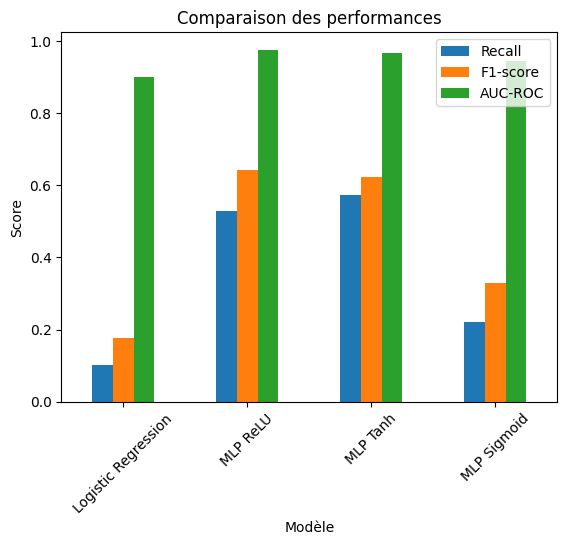

In [38]:
results_df.plot(x="Modèle", y=["Recall", "F1-score", "AUC-ROC"], kind="bar")
plt.title("Comparaison des performances")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

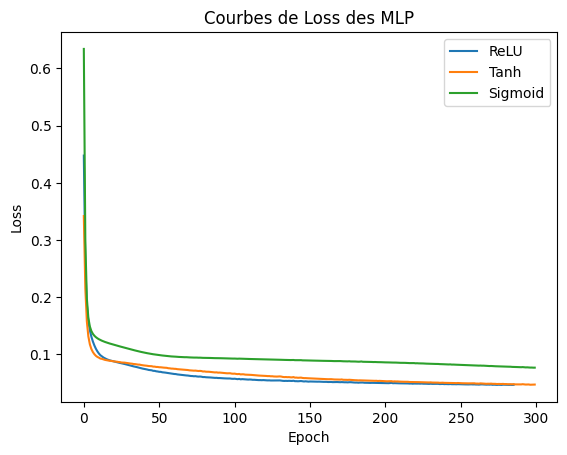

In [39]:
plt.plot(models["MLP ReLU"].loss_curve_, label="ReLU")
plt.plot(models["MLP Tanh"].loss_curve_, label="Tanh")
plt.plot(models["MLP Sigmoid"].loss_curve_, label="Sigmoid")
plt.title("Courbes de Loss des MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

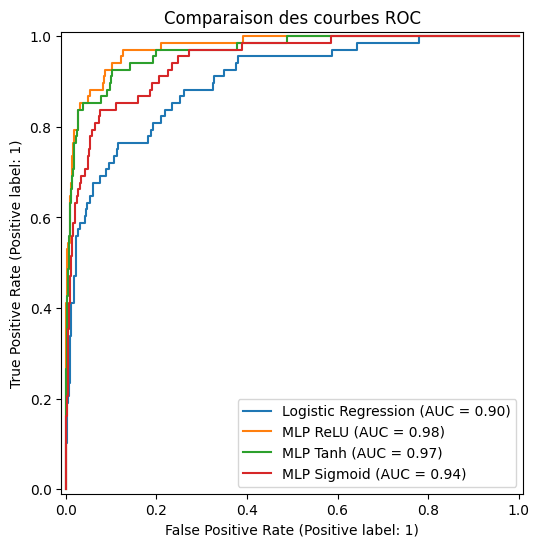

In [40]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("Comparaison des courbes ROC")
plt.show()

In [41]:
X_test_noise = X_test + np.random.normal(
    loc=0,
    scale=0.2,
    size=X_test.shape
)

In [42]:
robust_results = []

for name, model in models.items():

    y_pred = model.predict(X_test_noise)
    y_prob = model.predict_proba(X_test_noise)[:,1]

    robust_results.append({
        "Modèle": name,
        "Recall": recall_score(y_test,y_pred),
        "F1-score": f1_score(y_test,y_pred),
        "AUC-ROC": roc_auc_score(y_test,y_prob)
    })

robust_df = pd.DataFrame(robust_results)

robust_df

,Modèle,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.161765,0.250000,0.878258
1,MLP ReLU,0.514706,0.486111,0.953089
2,MLP Tanh,0.602941,0.585714,0.957351
3,MLP Sigmoid,0.250000,0.361702,0.936488


In [43]:
print("Résultats normaux")
display(results_df)

print("Résultats avec bruit")
display(robust_df)

Résultats normaux


,Modèle,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.102941,0.177215,0.899449
1,MLP ReLU,0.529412,0.642857,0.975543
2,MLP Tanh,0.573529,0.624000,0.966204
3,MLP Sigmoid,0.220588,0.329670,0.944229


Résultats avec bruit


,Modèle,Recall,F1-score,AUC-ROC
0,Logistic Regression,0.161765,0.250000,0.878258
1,MLP ReLU,0.514706,0.486111,0.953089
2,MLP Tanh,0.602941,0.585714,0.957351
3,MLP Sigmoid,0.250000,0.361702,0.936488
